In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
sns.set_theme(style="whitegrid")

(607, 12)
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


<Axes: >

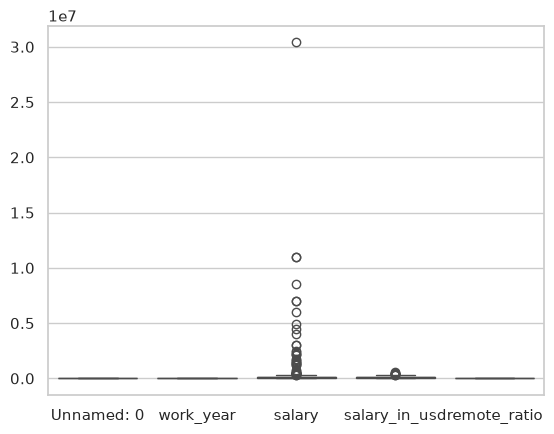

In [2]:
df=pd.read_csv(Path("../data/raw/ds_salaries.csv"))
print(df.shape)

df.head()
df.tail()
df.sample(5)
df.info()
df.describe()
df.shape
sns.boxplot(df)


In [3]:
df_clean_view = df.drop(columns=["Unnamed: 0"], errors="ignore")

df_clean_view.head()

columns_cleanView=df_clean_view.select_dtypes(include="object").columns.tolist()
int_col_cleanView=df_clean_view.select_dtypes(include=["int64","float64"]).columns.tolist()
print(columns_cleanView)
int_col_cleanView



['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


/tmp/ipykernel_110976/4111509692.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns_cleanView=df_clean_view.select_dtypes(include="object").columns.tolist()


['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

In [4]:
df_clean_view.isnull().sum()

df_clean_view.duplicated().sum()
np.nan

# df_clean_view.drop_duplicates(inplace=True)



nan

In [5]:
# No missing value treatment is needed because Step 1 and Step 3 checks show zero missing values.
# We do not fill `salary` because it will not be used as a model feature.
missing_values = df_clean_view.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [6]:
df_clean_view.duplicated().sum()
df_clean_view.drop_duplicates(inplace=True)


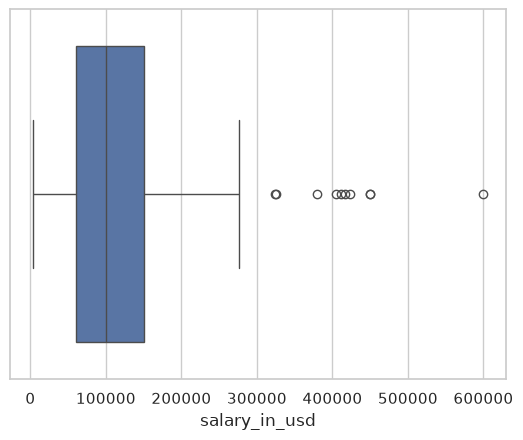

In [7]:
'# Data Leakage -'
df.drop(columns=["salary"], errors="ignore")
df.drop(columns=["salary_currency"], errors="ignore")

sns.boxplot(
    x=df_clean_view["salary_in_usd"]
)

plt.show()

In [8]:
Q1 = df_clean_view["salary_in_usd"].quantile(0.25)

Q3 = df_clean_view["salary_in_usd"].quantile(0.75)

IQR = Q3 - Q1
# print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)
df_clean_ = df_clean_view[
    (df_clean_view["salary_in_usd"] >= lower_bound) | (df_clean_view["salary_in_usd"] <= upper_bound)]

print(df_clean_)

-73107.5
283864.5
     work_year experience_level employment_type                   job_title  \
0         2020               MI              FT              Data Scientist   
1         2020               SE              FT  Machine Learning Scientist   
2         2020               SE              FT           Big Data Engineer   
3         2020               MI              FT        Product Data Analyst   
4         2020               SE              FT   Machine Learning Engineer   
..         ...              ...             ...                         ...   
602       2022               SE              FT               Data Engineer   
603       2022               SE              FT               Data Engineer   
604       2022               SE              FT                Data Analyst   
605       2022               SE              FT                Data Analyst   
606       2022               MI              FT                AI Scientist   

     salary salary_currency  sala

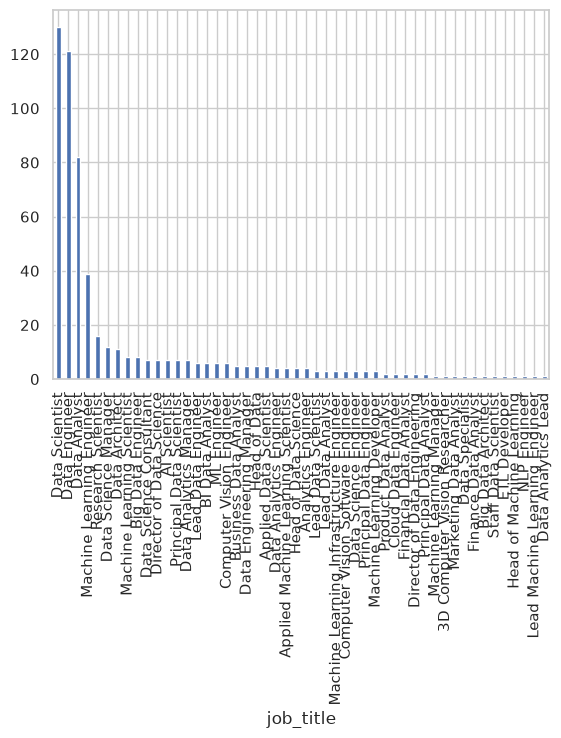

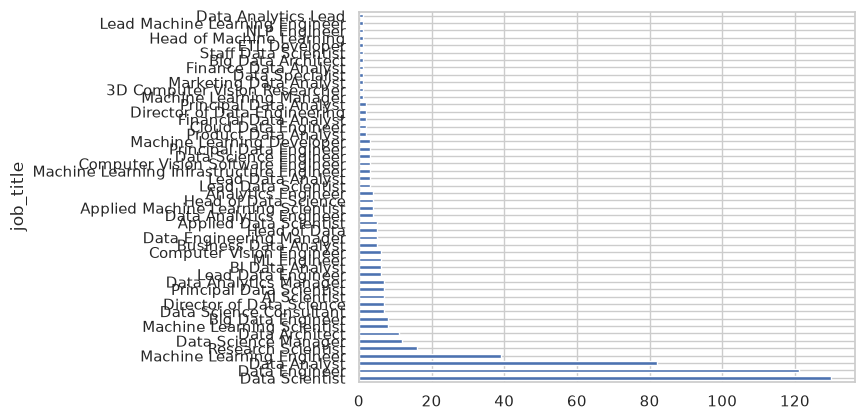

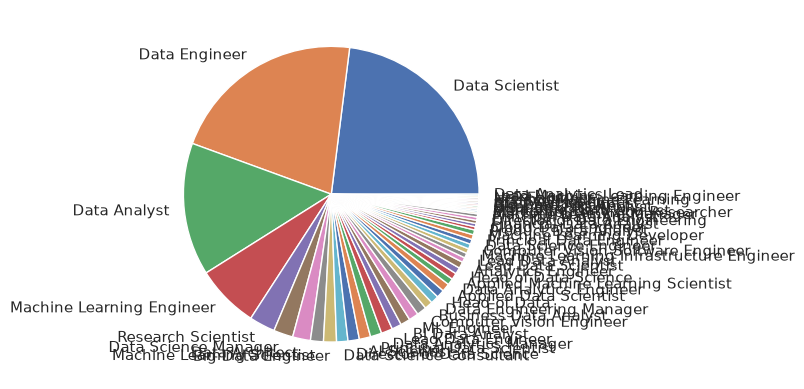

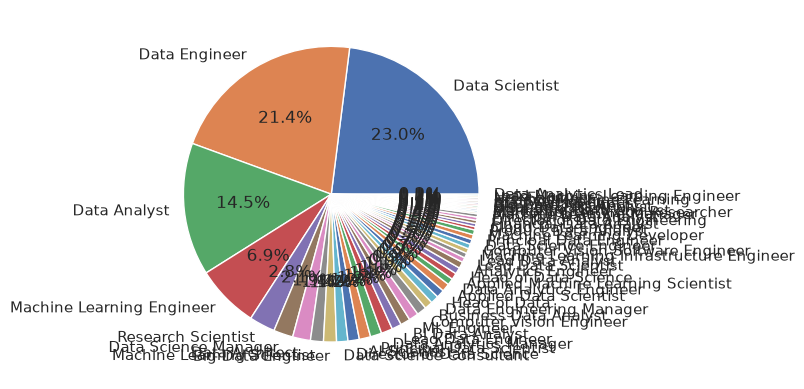

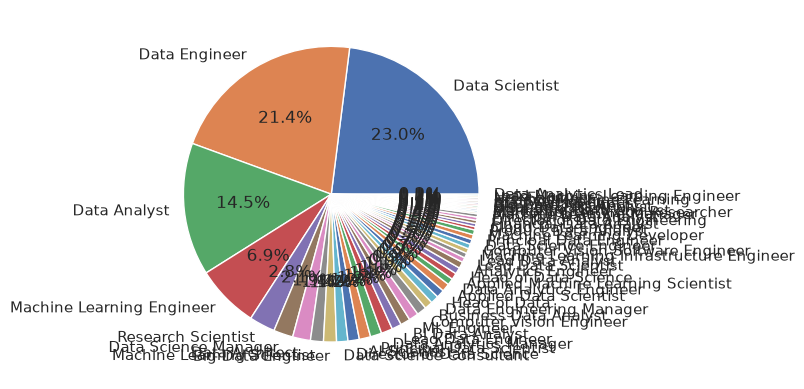

In [9]:
count=df_clean_view["job_title"].value_counts()

df_clean_view["job_title"].value_counts().plot(kind="bar")
plt.show()

df_clean_view["job_title"].value_counts().plot(kind="barh")
plt.show()

df_clean_view["job_title"].value_counts().plot(kind="pie")
plt.show()

df_clean_view["job_title"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

df_clean_view["job_title"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()





In [10]:
rare_titles = count[
    count < 5
]
print(rare_titles)

job_title
Data Analytics Engineer                     4
Applied Machine Learning Scientist          4
Head of Data Science                        4
Analytics Engineer                          4
Lead Data Scientist                         3
Lead Data Analyst                           3
Machine Learning Infrastructure Engineer    3
Computer Vision Software Engineer           3
Data Science Engineer                       3
Principal Data Engineer                     3
Machine Learning Developer                  3
Product Data Analyst                        2
Cloud Data Engineer                         2
Financial Data Analyst                      2
Director of Data Engineering                2
Principal Data Analyst                      2
Machine Learning Manager                    1
3D Computer Vision Researcher               1
Marketing Data Analyst                      1
Data Specialist                             1
Finance Data Analyst                        1
Big Data Architect      

In [11]:
# Removed Unnamed: 0 column.
# No missing values found.
# 42 duplicate rows removed.
# Outliers analyzed and retained.
# Rare categories identified.
# salary and salary_currency marked for removal during ML.

## Corrected Final Cleaning Flow

This section creates the final cleaned dataset for the next step.

Decisions:

- Remove `Unnamed: 0` because it is only an index-like column.
- Remove `salary` and `salary_currency` from the modeling dataset to avoid leakage.
- Keep `salary_in_usd` as the target variable.
- Keep duplicates removed after dropping the index-like column.
- Keep outliers for the first baseline model.
- Document rare categories but do not group them yet.

In [12]:
# Start again from raw data so the final cleaning flow is reproducible.
raw_path = Path("../data/raw/ds_salaries.csv")
df_raw = pd.read_csv(raw_path)

cleaned_df = df_raw.copy()

# Remove index-like column.
cleaned_df = cleaned_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Remove duplicate rows after dropping the index-like column.
duplicate_count_before = cleaned_df.duplicated().sum()
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicate_count_before}")
print(f"Cleaned shape after duplicate removal: {cleaned_df.shape}")

cleaned_df.head()

Duplicate rows removed: 42
Cleaned shape after duplicate removal: (565, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## Remove Leakage Columns

`salary` and `salary_currency` are removed from the final modeling dataset.

Reason:

- `salary_in_usd` is the target.
- `salary` is another salary value and can leak target information.
- `salary_currency` is directly connected to salary conversion and can also create leakage.

In [13]:
leakage_columns = ["salary", "salary_currency"]
cleaned_df = cleaned_df.drop(columns=leakage_columns, errors="ignore")

expected_columns = [
    "work_year",
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size",
    "salary_in_usd",
]

cleaned_df = cleaned_df[expected_columns]

print(cleaned_df.shape)
cleaned_df.head()

(565, 9)


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
0,2020,MI,FT,Data Scientist,DE,0,DE,L,79833
1,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S,260000
2,2020,SE,FT,Big Data Engineer,GB,50,GB,M,109024
3,2020,MI,FT,Product Data Analyst,HN,0,HN,S,20000
4,2020,SE,FT,Machine Learning Engineer,US,50,US,L,150000


## Rare Category Analysis

Rare categories can make one-hot encoding noisy because the model sees very few examples for those categories.

For the first baseline model, we only document rare categories. We do not group them yet.

In [14]:
rare_category_columns = [
    "job_title",
    "company_location",
    "employee_residence",
    "employment_type",
]

rare_threshold = 5

for column in rare_category_columns:
    counts = cleaned_df[column].value_counts()
    rare_categories = counts[counts < rare_threshold]

    print("=" * 80)
    print(f"Column: {column}")
    print(f"Total unique categories: {counts.shape[0]}")
    print(f"Rare categories with fewer than {rare_threshold} records: {rare_categories.shape[0]}")
    print(rare_categories.head(20))
    print()

Column: job_title
Total unique categories: 50
Rare categories with fewer than 5 records: 28
job_title
Data Analytics Engineer                     4
Applied Machine Learning Scientist          4
Head of Data Science                        4
Analytics Engineer                          4
Lead Data Scientist                         3
Lead Data Analyst                           3
Machine Learning Infrastructure Engineer    3
Computer Vision Software Engineer           3
Data Science Engineer                       3
Principal Data Engineer                     3
Machine Learning Developer                  3
Product Data Analyst                        2
Cloud Data Engineer                         2
Financial Data Analyst                      2
Director of Data Engineering                2
Principal Data Analyst                      2
Machine Learning Manager                    1
3D Computer Vision Researcher               1
Marketing Data Analyst                      1
Data Specialist         

## Save Cleaned Dataset

The cleaned dataset is saved to `data/processed/cleaned_salary_data.csv`.

This file will be used in Step 4: Feature Engineering.

In [15]:
processed_path = Path("../data/processed/cleaned_salary_data.csv")
processed_path.parent.mkdir(parents=True, exist_ok=True)

cleaned_df.to_csv(processed_path, index=False)

print(f"Saved cleaned dataset to: {processed_path}")
print(f"Final cleaned dataset shape: {cleaned_df.shape}")

Saved cleaned dataset to: ../data/processed/cleaned_salary_data.csv
Final cleaned dataset shape: (565, 9)


## Final Cleaning Summary

Cleaning decisions:

1. Removed `Unnamed: 0` because it is an index-like column.
2. No missing values were found, so no missing-value treatment was needed.
3. Duplicate rows were removed after dropping the index-like column.
4. Removed `salary` and `salary_currency` from the final modeling dataset to avoid data leakage.
5. Kept `salary_in_usd` as the target variable.
6. Outliers were analyzed but retained for the first baseline model.
7. Rare categories were identified but not grouped yet.
8. Saved the cleaned dataset to `data/processed/cleaned_salary_data.csv`.